In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

x = mnist.data
y = mnist.target

print('x shape:', x.shape)
print('y shape:', y.shape)

x shape: (70000, 784)
y shape: (70000,)


In [ ]:
x = x.astype("float32") / 255.0
y = y.astype("int64")

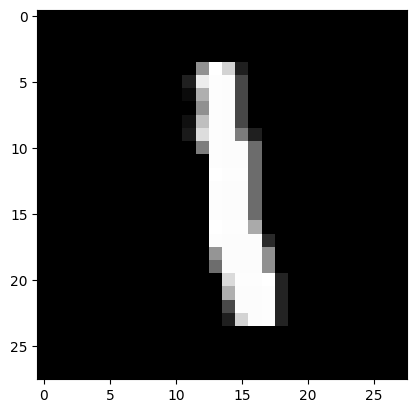

In [ ]:
plt.imshow(x[6].reshape(28, 28), cmap='gray')
plt.show()

In [ ]:
x_train = x[:60000]
y_train = y[:60000]

x_test = x[60000:]
y_test = y[60000:]

print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)


x_train: (60000, 784)
y_train: (60000,)
x_test: (10000, 784)
y_test: (10000,)


In [ ]:
y_train_ohe = np.zeros((y_train.shape[0], 10))
y_train_ohe[np.arange(y_train.shape[0]), y_train] = 1

y_test_ohe = np.zeros((y_test.shape[0], 10))
y_test_ohe[np.arange(y_test.shape[0]), y_test] = 1

print(y_train[0])
print(y_train_ohe[0])

5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
class NeuralNet:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.0005):
        self.lr = learning_rate

        # He initialization for ReLU
        self.w1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.w2 = np.random.randn(hidden_size, hidden_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, hidden_size))

        # Xavier initialization for output layer
        self.w3 = np.random.randn(hidden_size, output_size) * np.sqrt(1.0 / hidden_size)
        self.b3 = np.zeros((1, output_size))

        # Adam parameters
        self.beta1 = 0.9
        self.beta2 = 0.999
        self.epsilon = 1e-8

        self.t = 0

        self.mw1 = np.zeros_like(self.w1)
        self.mw2 = np.zeros_like(self.w2)
        self.mw3 = np.zeros_like(self.w3)

        self.mb1 = np.zeros_like(self.b1)
        self.mb2 = np.zeros_like(self.b2)
        self.mb3 = np.zeros_like(self.b3)

        self.vw1 = np.zeros_like(self.w1)
        self.vw2 = np.zeros_like(self.w2)
        self.vw3 = np.zeros_like(self.w3)

        self.vb1 = np.zeros_like(self.b1)
        self.vb2 = np.zeros_like(self.b2)
        self.vb3 = np.zeros_like(self.b3)

    def relu(self, z):
        return np.maximum(0, z)

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def forward_pass(self, x):
        self.x = x

        self.z1 = np.dot(x, self.w1) + self.b1
        self.hl1 = self.relu(self.z1)

        self.z2 = np.dot(self.hl1, self.w2) + self.b2
        self.hl2 = self.relu(self.z2)

        self.z3 = np.dot(self.hl2, self.w3) + self.b3
        self.hl3 = self.softmax(self.z3)

        return self.hl3

    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]

        y_pred = np.clip(y_pred, 1e-15, 1.0 - 1e-15)

        return -np.sum(y_true * np.log(y_pred)) / m

    def backward_pass(self, x, y_true):
        m = x.shape[0]

        # Output layer
        dz3 = self.hl3 - y_true

        dw3 = np.dot(self.hl2.T, dz3) / m
        db3 = np.sum(dz3, axis=0, keepdims=True) / m

        # Second hidden layer
        dz2 = np.dot(dz3, self.w3.T) * self.relu_derivative(self.z2)

        dw2 = np.dot(self.hl1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # First hidden layer
        dz1 = np.dot(dz2, self.w2.T) * self.relu_derivative(self.z1)

        dw1 = np.dot(x.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Adam optimizer
        self.t += 1

        # First moment
        self.mw1 = self.beta1 * self.mw1 + (1 - self.beta1) * dw1
        self.mw2 = self.beta1 * self.mw2 + (1 - self.beta1) * dw2
        self.mw3 = self.beta1 * self.mw3 + (1 - self.beta1) * dw3

        self.mb1 = self.beta1 * self.mb1 + (1 - self.beta1) * db1
        self.mb2 = self.beta1 * self.mb2 + (1 - self.beta1) * db2
        self.mb3 = self.beta1 * self.mb3 + (1 - self.beta1) * db3

        # Second moment
        self.vw1 = self.beta2 * self.vw1 + (1 - self.beta2) * (dw1 ** 2)
        self.vw2 = self.beta2 * self.vw2 + (1 - self.beta2) * (dw2 ** 2)
        self.vw3 = self.beta2 * self.vw3 + (1 - self.beta2) * (dw3 ** 2)

        self.vb1 = self.beta2 * self.vb1 + (1 - self.beta2) * (db1 ** 2)
        self.vb2 = self.beta2 * self.vb2 + (1 - self.beta2) * (db2 ** 2)
        self.vb3 = self.beta2 * self.vb3 + (1 - self.beta2) * (db3 ** 2)

        # Bias correction
        mw1_corrected = self.mw1 / (1 - self.beta1 ** self.t)
        mw2_corrected = self.mw2 / (1 - self.beta1 ** self.t)
        mw3_corrected = self.mw3 / (1 - self.beta1 ** self.t)

        mb1_corrected = self.mb1 / (1 - self.beta1 ** self.t)
        mb2_corrected = self.mb2 / (1 - self.beta1 ** self.t)
        mb3_corrected = self.mb3 / (1 - self.beta1 ** self.t)

        vw1_corrected = self.vw1 / (1 - self.beta2 ** self.t)
        vw2_corrected = self.vw2 / (1 - self.beta2 ** self.t)
        vw3_corrected = self.vw3 / (1 - self.beta2 ** self.t)

        vb1_corrected = self.vb1 / (1 - self.beta2 ** self.t)
        vb2_corrected = self.vb2 / (1 - self.beta2 ** self.t)
        vb3_corrected = self.vb3 / (1 - self.beta2 ** self.t)

        # Update weights
        self.w1 -= self.lr * mw1_corrected / (np.sqrt(vw1_corrected) + self.epsilon)
        self.w2 -= self.lr * mw2_corrected / (np.sqrt(vw2_corrected) + self.epsilon)
        self.w3 -= self.lr * mw3_corrected / (np.sqrt(vw3_corrected) + self.epsilon)

        self.b1 -= self.lr * mb1_corrected / (np.sqrt(vb1_corrected) + self.epsilon)
        self.b2 -= self.lr * mb2_corrected / (np.sqrt(vb2_corrected) + self.epsilon)
        self.b3 -= self.lr * mb3_corrected / (np.sqrt(vb3_corrected) + self.epsilon)

In [ ]:
model = NeuralNet(784, 128, 10, learning_rate=0.001)

print('w1:', model.w1.shape)
print('w2:', model.w2.shape)
print('w3:', model.w3.shape)

w1: (784, 128)
w2: (128, 128)
w3: (128, 10)


In [ ]:
epochs = 12
batch_size = 64

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    indices = np.random.permutation(len(x_train))
    x_train = x_train[indices]
    y_train_ohe = y_train_ohe[indices]
    y_train = y_train[indices]

    total_loss = 0
    correct = 0
    batches = 0

    for i in range(0, len(x_train), batch_size):
        x_batch = x_train[i:i + batch_size]
        y_batch = y_train_ohe[i:i + batch_size]

        y_pred = model.forward_pass(x_batch)
        loss = model.compute_loss(y_batch, y_pred)

        model.backward_pass(x_batch, y_batch)

        total_loss += loss
        correct += np.sum(np.argmax(y_pred, axis=1) == y_train[i:i + batch_size])
        batches += 1

    average_loss = total_loss / batches
    accuracy = correct / len(x_train)

    train_losses.append(average_loss)
    train_accuracies.append(accuracy)

    print('Epoch:', epoch + 1,
          'Loss:', round(average_loss, 4),
          'Accuracy:', round(accuracy * 100, 2), '%')


Epoch: 1 Loss: 0.2678 Accuracy: 92.22 %
Epoch: 2 Loss: 0.1077 Accuracy: 96.78 %
Epoch: 3 Loss: 0.074 Accuracy: 97.73 %
Epoch: 4 Loss: 0.055 Accuracy: 98.32 %
Epoch: 5 Loss: 0.0425 Accuracy: 98.66 %
Epoch: 6 Loss: 0.0342 Accuracy: 98.88 %
Epoch: 7 Loss: 0.029 Accuracy: 99.05 %
Epoch: 8 Loss: 0.0232 Accuracy: 99.28 %
Epoch: 9 Loss: 0.0204 Accuracy: 99.31 %
Epoch: 10 Loss: 0.0174 Accuracy: 99.43 %
Epoch: 11 Loss: 0.0172 Accuracy: 99.42 %
Epoch: 12 Loss: 0.014 Accuracy: 99.52 %


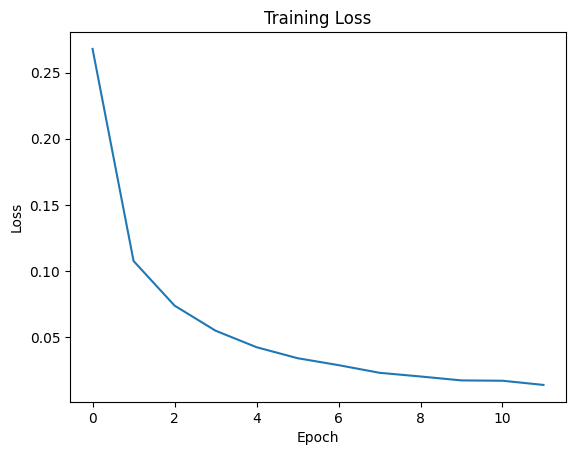

In [ ]:
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()


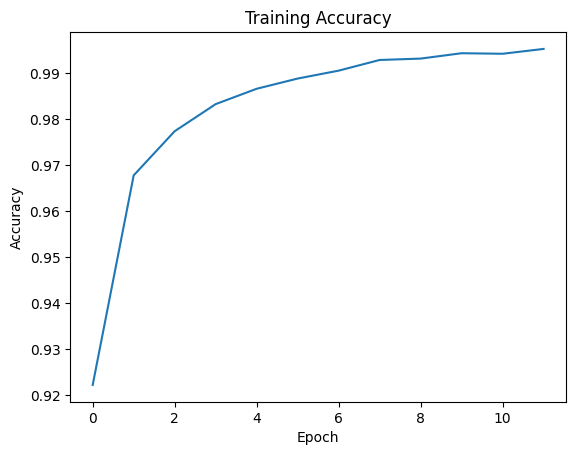

In [ ]:
plt.plot(train_accuracies)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.show()

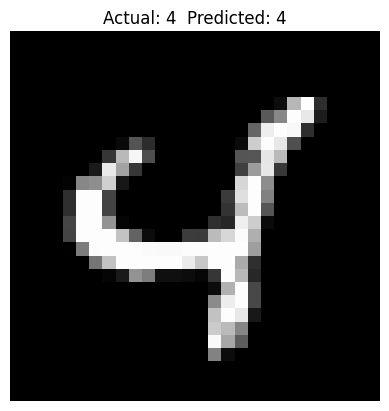

In [ ]:
index = 67

prediction = np.argmax(model.forward_pass(x_test[index:index + 1]))

plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title('Actual: ' + str(y_test[index]) +
          '  Predicted: ' + str(prediction))
plt.axis('off')
plt.show()

In [ ]:
y_test_pred = model.forward_pass(x_test)
test_predictions = np.argmax(y_test_pred, axis=1)

test_accuracy = np.mean(test_predictions == y_test)

print('Test Accuracy:', round(test_accuracy * 100, 2), '%')

Test Accuracy: 97.53 %


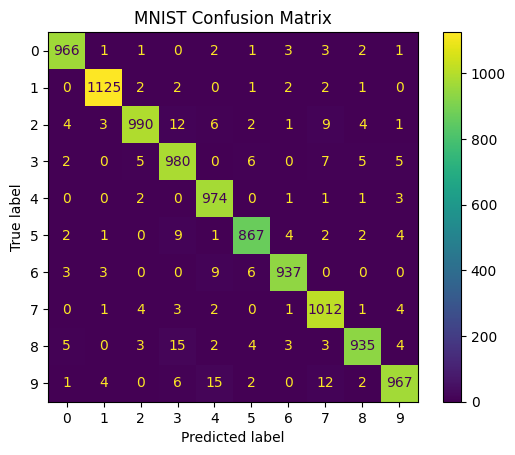

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, test_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('MNIST Confusion Matrix')
plt.show()